# GNOD - Song Recommendation System

## Business Understanding

Gnod is a music recommendation website that currently recommends artists based on the preferences of other users.

The objective of this project is to explore how Gnod could improve its music recommendations by adding two new possibilities:

1. Recommend songs that are currently popular around the world.
2. Recommend songs that are acoustically similar to a song selected by the user.

For this project, I will explore different data sources, clean and analyze the data, and use clustering techniques to group songs with similar characteristics.

The final goal is to create a first prototype of a song recommendation system and provide ideas for how Gnod could develop this feature further.

# GNOD - Song Recommendation System

1. Business Understanding
2. Data Sources
3. Import Libraries
4. Data Collection
5. Data Cleaning
6. Exploratory Data Analysis
7. Feature Engineering
8. PCA
9. K-Means Clustering
10. Song Recommendations
11. Business Conclusions
12. Future Improvements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import os
import io

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import os

os.makedirs("data", exist_ok=True)

print("Data folder is ready.")

Data folder is ready.


## Data Collection

For this project, I will use two different sources of information.

The first source is the Billboard Global 200, which will help identify songs that are currently popular around the world.

The second source is the Free Music Archive (FMA), which provides music metadata and audio features. These features will allow me to compare songs based on their acoustic characteristics and create groups of similar songs.

Using different sources is important because the two recommendation approaches have different objectives: one focuses on popularity and the other focuses on musical similarity.

In [3]:
billboard_url = (
    "https://raw.githubusercontent.com/"
    "KoreanThinker/billboard-json/main/"
    "billboard-global-200/recent.json"
)

response = requests.get(billboard_url)

print("Status code:", response.status_code)

Status code: 200


In [4]:
billboard_data = response.json()

print("Data type:", type(billboard_data))
print("\nAvailable keys:")
print(billboard_data.keys())

Data type: <class 'dict'>

Available keys:
dict_keys(['date', 'data'])


In [5]:
print(str(billboard_data)[:2000])

{'date': '2026-08-18', 'data': [{'name': 'Dai Dai (FIFA World Cup Official Song 2026)', 'artist': 'Shakira X Burna Boy', 'image': '', 'rank': 1, 'last_week_rank': 1, 'peak_rank': 0, 'weeks_on_chart': 12}, {'name': 'Hate That I Made You Love Me', 'artist': 'Ariana Grande', 'image': '', 'rank': 2, 'last_week_rank': 1, 'peak_rank': 0, 'weeks_on_chart': 11}, {'name': "Choosin' Texas", 'artist': 'Ella Langley', 'image': '', 'rank': 3, 'last_week_rank': 2, 'peak_rank': 0, 'weeks_on_chart': 42}, {'name': 'Petal', 'artist': 'Ariana Grande', 'image': '', 'rank': 4, 'last_week_rank': 2, 'peak_rank': 0, 'weeks_on_chart': 2}, {'name': 'Loser', 'artist': 'Tame Impala', 'image': 'https://charts-static.billboard.com/img/2025/09/tame-impala-nyr-loser-qfi-180x180.jpg', 'rank': 5, 'last_week_rank': 5, 'peak_rank': 0, 'weeks_on_chart': 2}, {'name': 'Beauty And A Beat', 'artist': 'Justin Bieber Featuring Nicki Minaj', 'image': 'https://charts-static.billboard.com/img/2012/07/justin-bieber-dj8-beautyandabe

In [6]:
billboard_df = pd.DataFrame(billboard_data["data"])

print("Number of songs:", len(billboard_df))
print("Number of columns:", len(billboard_df.columns))

billboard_df.head()

Number of songs: 200
Number of columns: 7


,name,artist,image,rank,last_week_rank,peak_rank,weeks_on_chart
0,Dai Dai (FIFA World Cup Official Song 2026),Shakira X Burna Boy,,1,1,0,12
1,Hate That I Made You Love Me,Ariana Grande,,2,1,0,11
2,Choosin' Texas,Ella Langley,,3,2,0,42
3,Petal,Ariana Grande,,4,2,0,2
4,Loser,Tame Impala,https://charts-static.billboard.com/img/2025/0...,5,5,0,2


In [7]:
print("Available columns:")
print(billboard_df.columns.tolist())

Available columns:
['name', 'artist', 'image', 'rank', 'last_week_rank', 'peak_rank', 'weeks_on_chart']


In [8]:
billboard_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   name            200 non-null    str  
 1   artist          200 non-null    str  
 2   image           200 non-null    str  
 3   rank            200 non-null    int64
 4   last_week_rank  200 non-null    int64
 5   peak_rank       200 non-null    int64
 6   weeks_on_chart  200 non-null    int64
dtypes: int64(4), str(3)
memory usage: 11.1 KB


In [9]:
billboard_df.isnull().sum()

name              0
artist            0
image             0
rank              0
last_week_rank    0
peak_rank         0
weeks_on_chart    0
dtype: int64

In [10]:
billboard_df.to_csv(
    "data/billboard_global_200.csv",
    index=False
)

print("Billboard data saved successfully.")

Billboard data saved successfully.


In [11]:
billboard_clean = billboard_df[
    [
        "name",
        "artist",
        "rank",
        "last_week_rank",
        "peak_rank",
        "weeks_on_chart"
    ]
].copy()

billboard_clean.head()

,name,artist,rank,last_week_rank,peak_rank,weeks_on_chart
0,Dai Dai (FIFA World Cup Official Song 2026),Shakira X Burna Boy,1,1,0,12
1,Hate That I Made You Love Me,Ariana Grande,2,1,0,11
2,Choosin' Texas,Ella Langley,3,2,0,42
3,Petal,Ariana Grande,4,2,0,2
4,Loser,Tame Impala,5,5,0,2


In [12]:
billboard_clean.describe()

,rank,last_week_rank,peak_rank,weeks_on_chart
count,200.000000,200.00000,200.0,200.000000
mean,100.500000,39.30500,0.0,72.715000
std,57.879185,44.57146,0.0,82.079467
min,1.000000,1.00000,0.0,1.000000
25%,50.750000,4.00000,0.0,12.000000
50%,100.500000,23.00000,0.0,36.000000
75%,150.250000,57.25000,0.0,112.250000
max,200.000000,183.00000,0.0,310.000000


In [13]:
billboard_clean["artist"].value_counts().head(10)

artist
Ariana Grande      11
Olivia Rodrigo      6
Michael Jackson     6
Bad Bunny           5
Bruno Mars          5
Taylor Swift        4
Ella Langley        3
sombr               3
Harry Styles        3
Rihanna             3
Name: count, dtype: int64

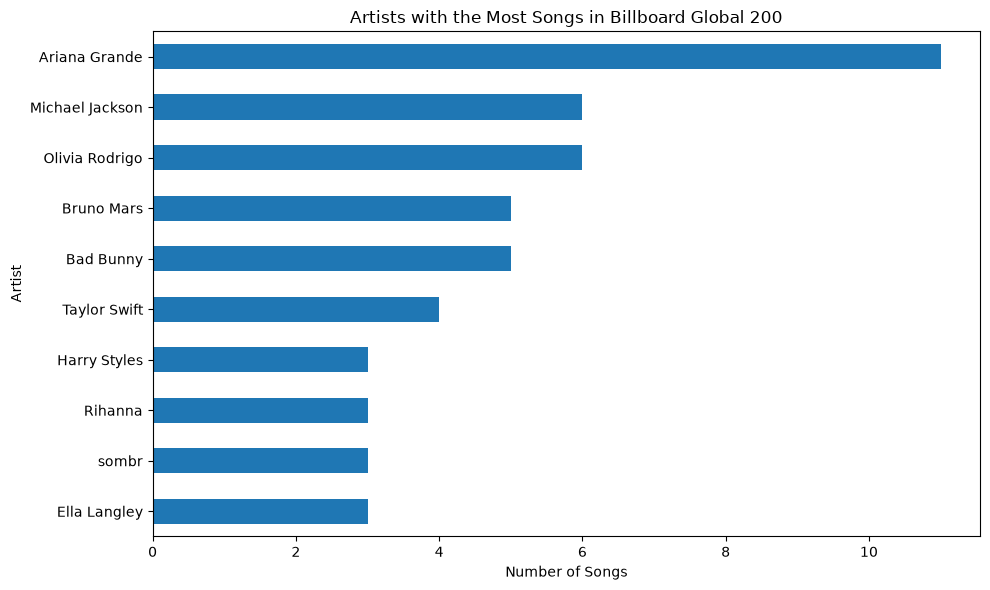

In [14]:
top_artists = billboard_clean["artist"].value_counts().head(10)

plt.figure(figsize=(10, 6))

top_artists.sort_values().plot(kind="barh")

plt.title("Artists with the Most Songs in Billboard Global 200")
plt.xlabel("Number of Songs")
plt.ylabel("Artist")

plt.tight_layout()
plt.show()

In [15]:
billboard_clean.to_csv(
    "data/billboard_global_200_clean.csv",
    index=False
)

print("Clean Billboard dataset saved successfully.")

Clean Billboard dataset saved successfully.


## Acoustic Music Data

To explore whether songs can be recommended based on their musical characteristics, I will use the Free Music Archive (FMA) dataset.

The dataset contains track metadata and pre-computed audio features. These features describe different characteristics of the music and can be used to compare tracks and identify groups of similar songs.

For this project, I will use the metadata and features only. I do not need to download the actual audio files.

In [16]:
fma_url = "https://os.unil.cloud.switch.ch/fma/fma_metadata.zip"

print("Starting FMA metadata download...")
print("This file is approximately 342 MB, so it may take a few minutes.")

Starting FMA metadata download...
This file is approximately 342 MB, so it may take a few minutes.


In [17]:
fma_response = requests.get(fma_url)

print("Status code:", fma_response.status_code)
print(
    "Downloaded:",
    round(len(fma_response.content) / (1024 * 1024), 2),
    "MB"
)

Status code: 200
Downloaded: 341.81 MB


In [19]:
fma_folder = "data/fma_metadata"

os.makedirs(fma_folder, exist_ok=True)

with zipfile.ZipFile(io.BytesIO(fma_response.content)) as z:
    z.extractall(fma_folder)

print("FMA metadata extracted successfully.")

FMA metadata extracted successfully.


In [20]:
for root, dirs, files in os.walk("data/fma_metadata"):
    for file in files:
        print(os.path.join(root, file))

data/fma_metadata\fma_metadata\checksums
data/fma_metadata\fma_metadata\echonest.csv
data/fma_metadata\fma_metadata\features.csv
data/fma_metadata\fma_metadata\genres.csv
data/fma_metadata\fma_metadata\not_found.pickle
data/fma_metadata\fma_metadata\raw_albums.csv
data/fma_metadata\fma_metadata\raw_artists.csv
data/fma_metadata\fma_metadata\raw_echonest.csv
data/fma_metadata\fma_metadata\raw_genres.csv
data/fma_metadata\fma_metadata\raw_tracks.csv
data/fma_metadata\fma_metadata\README.txt
data/fma_metadata\fma_metadata\tracks.csv


In [21]:
tracks_path = "data/fma_metadata/fma_metadata/tracks.csv"

tracks_df = pd.read_csv(
    tracks_path,
    header=[0, 1],
    index_col=0
)

print("Tracks dataset shape:", tracks_df.shape)

tracks_df.head()

Tracks dataset shape: (106574, 52)


album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                                                            \
         producer tags                 title tracks   type   
track_id                                                     
2             NaN   []  AWOL - A Way Of Life      7  Album   
3             NaN   []  AWOL - A Way Of Life      7  Album   
5             NaN   []  AWOL - A Way Of Life      7  Album   
10            NaN   []     Constant Hitmaker      2  Album   
20            NaN   []                 Niris     13  Album   

                       artist                       \
            active_year_begin      active_year_end   
track_id                                             
2         2006-01-01 00:00:00                  NaN   
3         2006-01-01 00:00:00                  NaN   
5         2006-01-01 00:00:00                  NaN   
10                        NaN                  NaN   
20        1990-01-01 00:00:00  2011-01-01 00:00:00   

                                                             \
                                          associated_labels   
track_id                                                      
2                                                       NaN   
3                                                       NaN   
5                                                       NaN   
10        Mexican Summer, Richie Records, Woodsist, Skul...   
20                                                      NaN   

                                                                      \
                                                        bio comments   
track_id                                                               
2         <p>A Way Of Life, A Collective of Hip-Hop from...        0   
3         <p>A Way Of Life, A Collective of Hip-Hop from...        0   
5         <p>A Way Of Life, A Collective of Hip-Hop from...        0   
10        <p><span style="font-family:Verdana, Geneva, A...        3   
20        <p>Songs written by: Nicky Cook</p>\n<p>VOCALS...        2   

                                                                           \
                 date_created favorites id   latitude            location   
track_id                                                                    
2         2008-11-26 01:42:32         9  1  40.058324          New Jersey   
3         2008-11-26 01:42:32         9  1  40.058324          New Jersey   
5         2008-11-26 01:42:32         9  1  40.058324          New Jersey   
10        2008-11-26 01:42:55        74  6        NaN                 NaN   
20        2008-11-26 01:42:52        10  4  51.895927  Colchester England   

                                                                        \
          longitude                                            members   
track_id                                         

In [22]:
print(tracks_df.columns)

MultiIndex([( 'album',          'comments'),
            ( 'album',      'date_created'),
            ( 'album',     'date_released'),
            ( 'album',          'engineer'),
            ( 'album',         'favorites'),
            ( 'album',                'id'),
            ( 'album',       'information'),
            ( 'album',           'listens'),
            ( 'album',          'producer'),
            ( 'album',              'tags'),
            ( 'album',             'title'),
            ( 'album',            'tracks'),
            ( 'album',              'type'),
            ('artist', 'active_year_begin'),
            ('artist',   'active_year_end'),
            ('artist', 'associated_labels'),
            ('artist',               'bio'),
            ('artist',          'comments'),
            ('artist',      'date_created'),
            ('artist',         'favorites'),
            ('artist',                'id'),
            ('artist',          'latitude'),
          

In [23]:
print("Number of tracks:", len(tracks_df))

Number of tracks: 106574


In [24]:
features_path = "data/fma_metadata/fma_metadata/features.csv"

features_sample = pd.read_csv(
    features_path,
    nrows=5
)

print("Features sample shape:", features_sample.shape)

features_sample.head()

Features sample shape: (5, 519)


,feature,chroma_cens,chroma_cens.1,chroma_cens.2,chroma_cens.3,chroma_cens.4,chroma_cens.5,chroma_cens.6,chroma_cens.7,chroma_cens.8,chroma_cens.9,chroma_cens.10,chroma_cens.11,chroma_cens.12,chroma_cens.13,chroma_cens.14,chroma_cens.15,chroma_cens.16,chroma_cens.17,chroma_cens.18,chroma_cens.19,chroma_cens.20,chroma_cens.21,chroma_cens.22,chroma_cens.23,chroma_cens.24,chroma_cens.25,chroma_cens.26,chroma_cens.27,chroma_cens.28,chroma_cens.29,chroma_cens.30,chroma_cens.31,chroma_cens.32,chroma_cens.33,chroma_cens.34,chroma_cens.35,chroma_cens.36,chroma_cens.37,chroma_cens.38,chroma_cens.39,chroma_cens.40,chroma_cens.41,chroma_cens.42,chroma_cens.43,chroma_cens.44,chroma_cens.45,chroma_cens.46,chroma_cens.47,chroma_cens.48,chroma_cens.49,chroma_cens.50,chroma_cens.51,chroma_cens.52,chroma_cens.53,chroma_cens.54,chroma_cens.55,chroma_cens.56,chroma_cens.57,chroma_cens.58,chroma_cens.59,chroma_cens.60,chroma_cens.61,chroma_cens.62,chroma_cens.63,chroma_cens.64,chroma_cens.65,chroma_cens.66,chroma_cens.67,chroma_cens.68,chroma_cens.69,chroma_cens.70,chroma_cens.71,chroma_cens.72,chroma_cens.73,chroma_cens.74,chroma_cens.75,chroma_cens.76,chroma_cens.77,chroma_cens.78,chroma_cens.79,chroma_cens.80,chroma_cens.81,chroma_cens.82,chroma_cens.83,chroma_cqt,chroma_cqt.1,chroma_cqt.2,chroma_cqt.3,chroma_cqt.4,chroma_cqt.5,chroma_cqt.6,chroma_cqt.7,chroma_cqt.8,chroma_cqt.9,chroma_cqt.10,chroma_cqt.11,chroma_cqt.12,chroma_cqt.13,chroma_cqt.14,chroma_cqt.15,chroma_cqt.16,chroma_cqt.17,chroma_cqt.18,chroma_cqt.19,chroma_cqt.20,chroma_cqt.21,chroma_cqt.22,chroma_cqt.23,chroma_cqt.24,chroma_cqt.25,chroma_cqt.26,chroma_cqt.27,chroma_cqt.28,chroma_cqt.29,chroma_cqt.30,chroma_cqt.31,chroma_cqt.32,chroma_cqt.33,chroma_cqt.34,chroma_cqt.35,chroma_cqt.36,chroma_cqt.37,chroma_cqt.38,chroma_cqt.39,chroma_cqt.40,chroma_cqt.41,chroma_cqt.42,chroma_cqt.43,chroma_cqt.44,chroma_cqt.45,chroma_cqt.46,chroma_cqt.47,chroma_cqt.48,chroma_cqt.49,chroma_cqt.50,chroma_cqt.51,chroma_cqt.52,chroma_cqt.53,chroma_cqt.54,chroma_cqt.55,chroma_cqt.56,chroma_cqt.57,chroma_cqt.58,chroma_cqt.59,chroma_cqt.60,chroma_cqt.61,chroma_cqt.62,chroma_cqt.63,chroma_cqt.64,chroma_cqt.65,chroma_cqt.66,chroma_cqt.67,chroma_cqt.68,chroma_cqt.69,chroma_cqt.70,chroma_cqt.71,chroma_cqt.72,chroma_cqt.73,chroma_cqt.74,chroma_cqt.75,chroma_cqt.76,chroma_cqt.77,chroma_cqt.78,chroma_cqt.79,chroma_cqt.80,chroma_cqt.81,chroma_cqt.82,chroma_cqt.83,chroma_stft,chroma_stft.1,chroma_stft.2,chroma_stft.3,chroma_stft.4,chroma_stft.5,chroma_stft.6,chroma_stft.7,chroma_stft.8,chroma_stft.9,chroma_stft.10,chroma_stft.11,chroma_stft.12,chroma_stft.13,chroma_stft.14,chroma_stft.15,chroma_stft.16,chroma_stft.17,chroma_stft.18,chroma_stft.19,chroma_stft.20,chroma_stft.21,chroma_stft.22,chroma_stft.23,chroma_stft.24,chroma_stft.25,chroma_stft.26,chroma_stft.27,chroma_stft.28,chroma_stft.29,chroma_stft.30,chroma_stft.31,chroma_stft.32,chroma_stft.33,chroma_stft.34,chroma_stft.35,chroma_stft.36,chroma_stft.37,chroma_stft.38,chroma_stft.39,chroma_stft.40,chroma_stft.41,chroma_stft.42,chroma_stft.43,chroma_stft.44,chroma_stft.45,chroma_stft.46,chroma_stft.47,chroma_stft.48,chroma_stft.49,chroma_stft.50,chroma_stft.51,chroma_stft.52,chroma_stft.53,chroma_stft.54,chroma_stft.55,chroma_stft.56,chroma_stft.57,chroma_stft.58,chroma_stft.59,chroma_stft.60,chroma_stft.61,chroma_stft.62,chroma_stft.63,chroma_stft.64,chroma_stft.65,chroma_stft.66,chroma_stft.67,chroma_stft.68,chroma_stft.69,chroma_stft.70,chroma_stft.71,chroma_stft.72,chroma_stft.73,chroma_stft.74,chroma_stft.75,chroma_stft.76,chroma_stft.77,chroma_stft.78,chroma_stft.79,chroma_stft.80,chroma_stft.81,chroma_stft.82,chroma_stft.83,mfcc,mfcc.1,mfcc.2,mfcc.3,mfcc.4,mfcc.5,mfcc.6,mfcc.7,mfcc.8,mfcc.9,mfcc.10,mfcc.11,mfcc.12,mfcc.13,mfcc.14,mfcc.15,mfcc.16,mfcc.17,mfcc.18,mfcc.19,mfcc.20,mfcc.21,mfcc.22,mfcc.23,mfcc.24,mfcc.25,mfcc.26,mfcc.27,mfcc.28,mfcc.29,mfcc.30,mfcc.31,mfcc.32,mfcc.33,mfcc.34,mfcc.35,mfcc.36,mfcc.37,mfcc.38,mfcc.39,mfcc.40,mfcc.41,mfcc.42

In [25]:
print(features_sample.columns.tolist())

['feature', 'chroma_cens', 'chroma_cens.1', 'chroma_cens.2', 'chroma_cens.3', 'chroma_cens.4', 'chroma_cens.5', 'chroma_cens.6', 'chroma_cens.7', 'chroma_cens.8', 'chroma_cens.9', 'chroma_cens.10', 'chroma_cens.11', 'chroma_cens.12', 'chroma_cens.13', 'chroma_cens.14', 'chroma_cens.15', 'chroma_cens.16', 'chroma_cens.17', 'chroma_cens.18', 'chroma_cens.19', 'chroma_cens.20', 'chroma_cens.21', 'chroma_cens.22', 'chroma_cens.23', 'chroma_cens.24', 'chroma_cens.25', 'chroma_cens.26', 'chroma_cens.27', 'chroma_cens.28', 'chroma_cens.29', 'chroma_cens.30', 'chroma_cens.31', 'chroma_cens.32', 'chroma_cens.33', 'chroma_cens.34', 'chroma_cens.35', 'chroma_cens.36', 'chroma_cens.37', 'chroma_cens.38', 'chroma_cens.39', 'chroma_cens.40', 'chroma_cens.41', 'chroma_cens.42', 'chroma_cens.43', 'chroma_cens.44', 'chroma_cens.45', 'chroma_cens.46', 'chroma_cens.47', 'chroma_cens.48', 'chroma_cens.49', 'chroma_cens.50', 'chroma_cens.51', 'chroma_cens.52', 'chroma_cens.53', 'chroma_cens.54', 'chroma_ce

In [26]:
features_header = pd.read_csv(
    features_path,
    header=[0, 1, 2],
    index_col=0,
    nrows=0
)

print("Number of feature columns:", len(features_header.columns))

features_header.columns

Number of feature columns: 518


MultiIndex([('chroma_cens', 'kurtosis', '01'),
            ('chroma_cens', 'kurtosis', '02'),
            ('chroma_cens', 'kurtosis', '03'),
            ('chroma_cens', 'kurtosis', '04'),
            ('chroma_cens', 'kurtosis', '05'),
            ('chroma_cens', 'kurtosis', '06'),
            ('chroma_cens', 'kurtosis', '07'),
            ('chroma_cens', 'kurtosis', '08'),
            ('chroma_cens', 'kurtosis', '09'),
            ('chroma_cens', 'kurtosis', '10'),
            ...
            (    'tonnetz',      'std', '04'),
            (    'tonnetz',      'std', '05'),
            (    'tonnetz',      'std', '06'),
            (        'zcr', 'kurtosis', '01'),
            (        'zcr',      'max', '01'),
            (        'zcr',     'mean', '01'),
            (        'zcr',   'median', '01'),
            (        'zcr',      'min', '01'),
            (        'zcr',     'skew', '01'),
            (        'zcr',      'std', '01')],
           names=['feature', 'statistics', 

In [27]:
feature_families = sorted(
    set(column[0] for column in features_header.columns)
)

print("Available acoustic feature families:")
for family in feature_families:
    print("-", family)

Available acoustic feature families:
- chroma_cens
- chroma_cqt
- chroma_stft
- mfcc
- rmse
- spectral_bandwidth
- spectral_centroid
- spectral_contrast
- spectral_rolloff
- tonnetz
- zcr


In [28]:
features_header = pd.read_csv(
    features_path,
    header=[0, 1, 2],
    index_col=0,
    nrows=0
)

print("Number of feature columns:", len(features_header.columns))

features_header.columns

Number of feature columns: 518


MultiIndex([('chroma_cens', 'kurtosis', '01'),
            ('chroma_cens', 'kurtosis', '02'),
            ('chroma_cens', 'kurtosis', '03'),
            ('chroma_cens', 'kurtosis', '04'),
            ('chroma_cens', 'kurtosis', '05'),
            ('chroma_cens', 'kurtosis', '06'),
            ('chroma_cens', 'kurtosis', '07'),
            ('chroma_cens', 'kurtosis', '08'),
            ('chroma_cens', 'kurtosis', '09'),
            ('chroma_cens', 'kurtosis', '10'),
            ...
            (    'tonnetz',      'std', '04'),
            (    'tonnetz',      'std', '05'),
            (    'tonnetz',      'std', '06'),
            (        'zcr', 'kurtosis', '01'),
            (        'zcr',      'max', '01'),
            (        'zcr',     'mean', '01'),
            (        'zcr',   'median', '01'),
            (        'zcr',      'min', '01'),
            (        'zcr',     'skew', '01'),
            (        'zcr',      'std', '01')],
           names=['feature', 'statistics', 

In [29]:
feature_families = sorted(
    set(column[0] for column in features_header.columns)
)

print("Available acoustic feature families:")
for family in feature_families:
    print("-", family)

Available acoustic feature families:
- chroma_cens
- chroma_cqt
- chroma_stft
- mfcc
- rmse
- spectral_bandwidth
- spectral_centroid
- spectral_contrast
- spectral_rolloff
- tonnetz
- zcr


In [30]:
selected_features = [
    "mfcc",
    "rmse",
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_contrast",
    "spectral_rolloff",
    "zcr"
]

selected_columns = [
    column
    for column in features_header.columns
    if column[0] in selected_features and column[1] == "mean"
]

print("Selected feature columns:", len(selected_columns))

for column in selected_columns:
    print(column)

Selected feature columns: 32
('mfcc', 'mean', '01')
('mfcc', 'mean', '02')
('mfcc', 'mean', '03')
('mfcc', 'mean', '04')
('mfcc', 'mean', '05')
('mfcc', 'mean', '06')
('mfcc', 'mean', '07')
('mfcc', 'mean', '08')
('mfcc', 'mean', '09')
('mfcc', 'mean', '10')
('mfcc', 'mean', '11')
('mfcc', 'mean', '12')
('mfcc', 'mean', '13')
('mfcc', 'mean', '14')
('mfcc', 'mean', '15')
('mfcc', 'mean', '16')
('mfcc', 'mean', '17')
('mfcc', 'mean', '18')
('mfcc', 'mean', '19')
('mfcc', 'mean', '20')
('rmse', 'mean', '01')
('spectral_bandwidth', 'mean', '01')
('spectral_centroid', 'mean', '01')
('spectral_contrast', 'mean', '01')
('spectral_contrast', 'mean', '02')
('spectral_contrast', 'mean', '03')
('spectral_contrast', 'mean', '04')
('spectral_contrast', 'mean', '05')
('spectral_contrast', 'mean', '06')
('spectral_contrast', 'mean', '07')
('spectral_rolloff', 'mean', '01')
('zcr', 'mean', '01')


In [31]:
print("\nTotal acoustic variables selected:", len(selected_columns))


Total acoustic variables selected: 32


In [33]:
# Read the FMA features file with the original 3-level header
features_all = pd.read_csv(
    features_path,
    header=[0, 1, 2],
    index_col=0
)

print("Full features dataset:", features_all.shape)

# Select only our 32 chosen acoustic variables
features_df = features_all[selected_columns].copy()

print("Selected acoustic features:", features_df.shape)

features_df.head()

Full features dataset: (106574, 518)
Selected acoustic features: (106574, 32)


feature           mfcc                                               \
statistics        mean                                                
number              01          02         03         04         05   
track_id                                                              
2          -163.772964  116.696678 -41.753826  29.144329 -15.050158   
3          -159.004166  120.158501 -33.233562  47.342003  -6.247318   
5          -205.440491  132.215073 -16.085823  41.514759  -7.642954   
10         -135.864822  157.040085 -53.453247  17.198896   6.868035   
20         -135.135895  114.814178  12.354540  19.764219  18.670799   

feature                                                                    \
statistics                                                                  
number             06         07         08        09        10        11   
track_id                                                                    
2           18.879372  -8.918165  12.002118 -4.253151  1.359791 -2.683000   
3           31.405355  -5.261811  11.618972 -1.595837  5.132730 -3.422679   
5           16.942802  -5.651261   9.569445  0.503157  8.673513 -8.271377   
10          13.934344 -11.749298   8.360711 -5.130381  0.233845 -5.421206   
20          19.643862   3.572509  12.124897 -2.285183  8.835210 -0.805463   

feature                                                                 \
statistics                                                               
number            12        13        14        15        16        17   
track_id                                                                 
2          -0.794632 -6.920971 -3.655366  1.465213  0.201078  3.998204   
3           6.949284 -4.175256 -3.528815  0.274716 -2.270682  1.090475   
5           0.594473 -0.340203  2.377888  7.899487  1.947641  7.441950   
10          1.679479 -6.218249  1.844195 -4.099704  0.779950 -0.559577   
20          4.082942  0.214245  3.875917 -0.235324  0.390292 -0.572471   

feature                                       rmse spectral_bandwidth  \
statistics                                    mean               mean   
number            18        19        20        01                 01   
track_id                                                                
2          -2.114676  0.116842 -5.785884  3.188761        1607.474365   
3          -2.343884  0.471821 -1.546707  3.607359        1736.961426   
5          -1.739911  0.278015 -5.489016  3.251386        1512.917358   
10         -1.018324 -3.807545 -0.679533  3.893810        1420.259644   
20          2.779172  2.431258  3.031117  4.600440        2489.015625   

feature    spectral_centroid spectral_contrast                        \
statistics              mean              mean                         
number                    01                01         02         03   
track_id                                                               
2                1639.583252         18.005175  15.363138  17.129013   
3                1763.012451         15.732023  15.046037  17.374632   
5                1292.958130         17.097452  15.969444  18.646988   
10               1360.028687         19.177481  14.281867  15.510051   
20               1732.971802         16.042891  16.161236  17.701635   

feature                                                spectral_rolloff  \
statistics                                                         mean   
number             04         05         06         07               01   
track_id                                                                  
2           17.157160  18.087046  17.616112  38.268646      3267.804688   
3           17.210331  18.180691  18.898478  39.201202      3514.619629   
5           16.973648  17.292145  19.255819  36.413609      2773.931885   
10          16.541273  20.316816  18.967014  34.886196      2603.491943   
20          18.375206  18.423019  16.482040  18.999117      4201.346191   

feature         

In [34]:
print("Missing values:", features_df.isnull().sum().sum())
print("Number of tracks:", len(features_df))
print("Number of acoustic variables:", features_df.shape[1])

Missing values: 0
Number of tracks: 106574
Number of acoustic variables: 32


In [35]:
features_df.info()

<class 'pandas.DataFrame'>
Index: 106574 entries, 2 to 155320
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   (mfcc, mean, 01)                106574 non-null  float64
 1   (mfcc, mean, 02)                106574 non-null  float64
 2   (mfcc, mean, 03)                106574 non-null  float64
 3   (mfcc, mean, 04)                106574 non-null  float64
 4   (mfcc, mean, 05)                106574 non-null  float64
 5   (mfcc, mean, 06)                106574 non-null  float64
 6   (mfcc, mean, 07)                106574 non-null  float64
 7   (mfcc, mean, 08)                106574 non-null  float64
 8   (mfcc, mean, 09)                106574 non-null  float64
 9   (mfcc, mean, 10)                106574 non-null  float64
 10  (mfcc, mean, 11)                106574 non-null  float64
 11  (mfcc, mean, 12)                106574 non-null  float64
 12  (mfcc, mean, 13)                

In [36]:
features_df.describe().T.head(10)

count        mean        std         min  \
feature statistics number                                                
mfcc    mean       01      106574.0 -211.642165  98.899776 -985.113586   
                   02      106574.0  146.674911  34.954127 -167.738709   
                   03      106574.0  -11.779146  31.190895 -169.286057   
                   04      106574.0   27.222940  20.112607 -126.916214   
                   05      106574.0    2.859642  13.634194  -90.218658   
                   06      106574.0   12.821505  11.942905  -63.234154   
                   07      106574.0   -2.610632   9.862855  -86.041115   
                   08      106574.0    5.553350   9.161534  -52.843803   
                   09      106574.0   -1.665927   7.171505  -49.251720   
                   10      106574.0    1.890414   7.779095  -42.315605   

                                  25%         50%         75%         max  
feature statistics number                                                  
mfcc    mean       01     -272.767136 -201.773087 -141.653267  142.545715  
                   02      125.483107  147.689522  168.883389  275.533569  
                   03      -32.468681  -13.032348    6.794909  133.530075  
                   04       16.745510   29.332815   40.219603  125.015114  
                   05       -5.726558    2.504678   11.235320   80.911392  
                   06        6.035256   13.805487   20.706744   73.760307  
                   07       -8.358903   -2.339961    3.550273   80.147697  
                   08        0.381807    6.240748   11.506720   64.412994  
                   09       -5.844386   -1.463109    2.765039   52.927296  
                   10       -2.681928    2.380264    7.020095   56.567822

In [37]:
# Keep the useful metadata from the FMA tracks dataset
track_metadata = tracks_df[
    [
        ("track", "title"),
        ("track", "genre_top")
    ]
].copy()

track_metadata.columns = ["title", "genre"]

track_metadata.index.name = "track_id"

track_metadata.head()

,title,genre
track_id,,
2,Food,Hip-Hop
3,Electric Ave,Hip-Hop
5,This World,Hip-Hop
10,Freeway,Pop
20,Spiritual Level,NaN


In [39]:
# Flatten the MultiIndex columns into simple names

features_df.columns = [
    f"{feature}_{number}"
    for feature, statistic, number in features_df.columns
]

print("Number of acoustic features:", len(features_df.columns))

features_df.head()

Number of acoustic features: 32


,mfcc_01,mfcc_02,mfcc_03,mfcc_04,mfcc_05,mfcc_06,mfcc_07,mfcc_08,mfcc_09,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,rmse_01,spectral_bandwidth_01,spectral_centroid_01,spectral_contrast_01,spectral_contrast_02,spectral_contrast_03,spectral_contrast_04,spectral_contrast_05,spectral_contrast_06,spectral_contrast_07,spectral_rolloff_01,zcr_01
track_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,-163.772964,116.696678,-41.753826,29.144329,-15.050158,18.879372,-8.918165,12.002118,-4.253151,1.359791,-2.683000,-0.794632,-6.920971,-3.655366,1.465213,0.201078,3.998204,-2.114676,0.116842,-5.785884,3.188761,1607.474365,1639.583252,18.005175,15.363138,17.129013,17.157160,18.087046,17.616112,38.268646,3267.804688,0.085629
3,-159.004166,120.158501,-33.233562,47.342003,-6.247318,31.405355,-5.261811,11.618972,-1.595837,5.132730,-3.422679,6.949284,-4.175256,-3.528815,0.274716,-2.270682,1.090475,-2.343884,0.471821,-1.546707,3.607359,1736.961426,1763.012451,15.732023,15.046037,17.374632,17.210331,18.180691,18.898478,39.201202,3514.619629,0.084578
5,-205.440491,132.215073,-16.085823,41.514759,-7.642954,16.942802,-5.651261,9.569445,0.503157,8.673513,-8.271377,0.594473,-0.340203,2.377888,7.899487,1.947641,7.441950,-1.739911,0.278015,-5.489016,3.251386,1512.917358,1292.958130,17.097452,15.969444,18.646988,16.973648,17.292145,19.255819,36.413609,2773.931885,0.053114
10,-135.864822,157.040085,-53.453247,17.198896,6.868035,13.934344,-11.749298,8.360711,-5.130381,0.233845,-5.421206,1.679479,-6.218249,1.844195,-4.099704,0.779950,-0.559577,-1.018324,-3.807545,-0.679533,3.893810,1420.259644,1360.028687,19.177481,14.281867,15.510051,16.541273,20.316816,18.967014,34.886196,2603.491943,0.077515
20,-135.135895,114.814178,12.354540,19.764219,18.670799,19.643862,3.572509,12.124897,-2.285183,8.835210,-0.805463,4.082942,0.214245,3.875917,-0.235324,0.390292,-0.572471,2.779172,2.431258,3.031117,4.600440,2489.015625,1732.971802,16.042891,16.161236,17.701635,18.375206,18.423019,16.482040,18.999117,4201.346191,0.047225


In [40]:
fma_df = track_metadata.join(features_df, how="inner")

print("Final FMA dataset shape:", fma_df.shape)

fma_df.head()

Final FMA dataset shape: (106574, 34)


,title,genre,mfcc_01,mfcc_02,mfcc_03,mfcc_04,mfcc_05,mfcc_06,mfcc_07,mfcc_08,mfcc_09,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,rmse_01,spectral_bandwidth_01,spectral_centroid_01,spectral_contrast_01,spectral_contrast_02,spectral_contrast_03,spectral_contrast_04,spectral_contrast_05,spectral_contrast_06,spectral_contrast_07,spectral_rolloff_01,zcr_01
track_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,Food,Hip-Hop,-163.772964,116.696678,-41.753826,29.144329,-15.050158,18.879372,-8.918165,12.002118,-4.253151,1.359791,-2.683000,-0.794632,-6.920971,-3.655366,1.465213,0.201078,3.998204,-2.114676,0.116842,-5.785884,3.188761,1607.474365,1639.583252,18.005175,15.363138,17.129013,17.157160,18.087046,17.616112,38.268646,3267.804688,0.085629
3,Electric Ave,Hip-Hop,-159.004166,120.158501,-33.233562,47.342003,-6.247318,31.405355,-5.261811,11.618972,-1.595837,5.132730,-3.422679,6.949284,-4.175256,-3.528815,0.274716,-2.270682,1.090475,-2.343884,0.471821,-1.546707,3.607359,1736.961426,1763.012451,15.732023,15.046037,17.374632,17.210331,18.180691,18.898478,39.201202,3514.619629,0.084578
5,This World,Hip-Hop,-205.440491,132.215073,-16.085823,41.514759,-7.642954,16.942802,-5.651261,9.569445,0.503157,8.673513,-8.271377,0.594473,-0.340203,2.377888,7.899487,1.947641,7.441950,-1.739911,0.278015,-5.489016,3.251386,1512.917358,1292.958130,17.097452,15.969444,18.646988,16.973648,17.292145,19.255819,36.413609,2773.931885,0.053114
10,Freeway,Pop,-135.864822,157.040085,-53.453247,17.198896,6.868035,13.934344,-11.749298,8.360711,-5.130381,0.233845,-5.421206,1.679479,-6.218249,1.844195,-4.099704,0.779950,-0.559577,-1.018324,-3.807545,-0.679533,3.893810,1420.259644,1360.028687,19.177481,14.281867,15.510051,16.541273,20.316816,18.967014,34.886196,2603.491943,0.077515
20,Spiritual Level,NaN,-135.135895,114.814178,12.354540,19.764219,18.670799,19.643862,3.572509,12.124897,-2.285183,8.835210,-0.805463,4.082942,0.214245,3.875917,-0.235324,0.390292,-0.572471,2.779172,2.431258,3.031117,4.600440,2489.015625,1732.971802,16.042891,16.161236,17.701635,18.375206,18.423019,16.482040,18.999117,4201.346191,0.047225


In [43]:
print("Acoustic features shape:", features_df.shape)

Acoustic features shape: (106574, 32)


In [47]:
# Select only the acoustic variables for clustering

acoustic_features = fma_df.drop(
    columns=["title", "genre"]
).copy()

print("Acoustic dataset shape:", acoustic_features.shape)
acoustic_features.head()

Acoustic dataset shape: (106574, 32)


,mfcc_01,mfcc_02,mfcc_03,mfcc_04,mfcc_05,mfcc_06,mfcc_07,mfcc_08,mfcc_09,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,rmse_01,spectral_bandwidth_01,spectral_centroid_01,spectral_contrast_01,spectral_contrast_02,spectral_contrast_03,spectral_contrast_04,spectral_contrast_05,spectral_contrast_06,spectral_contrast_07,spectral_rolloff_01,zcr_01
track_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,-163.772964,116.696678,-41.753826,29.144329,-15.050158,18.879372,-8.918165,12.002118,-4.253151,1.359791,-2.683000,-0.794632,-6.920971,-3.655366,1.465213,0.201078,3.998204,-2.114676,0.116842,-5.785884,3.188761,1607.474365,1639.583252,18.005175,15.363138,17.129013,17.157160,18.087046,17.616112,38.268646,3267.804688,0.085629
3,-159.004166,120.158501,-33.233562,47.342003,-6.247318,31.405355,-5.261811,11.618972,-1.595837,5.132730,-3.422679,6.949284,-4.175256,-3.528815,0.274716,-2.270682,1.090475,-2.343884,0.471821,-1.546707,3.607359,1736.961426,1763.012451,15.732023,15.046037,17.374632,17.210331,18.180691,18.898478,39.201202,3514.619629,0.084578
5,-205.440491,132.215073,-16.085823,41.514759,-7.642954,16.942802,-5.651261,9.569445,0.503157,8.673513,-8.271377,0.594473,-0.340203,2.377888,7.899487,1.947641,7.441950,-1.739911,0.278015,-5.489016,3.251386,1512.917358,1292.958130,17.097452,15.969444,18.646988,16.973648,17.292145,19.255819,36.413609,2773.931885,0.053114
10,-135.864822,157.040085,-53.453247,17.198896,6.868035,13.934344,-11.749298,8.360711,-5.130381,0.233845,-5.421206,1.679479,-6.218249,1.844195,-4.099704,0.779950,-0.559577,-1.018324,-3.807545,-0.679533,3.893810,1420.259644,1360.028687,19.177481,14.281867,15.510051,16.541273,20.316816,18.967014,34.886196,2603.491943,0.077515
20,-135.135895,114.814178,12.354540,19.764219,18.670799,19.643862,3.572509,12.124897,-2.285183,8.835210,-0.805463,4.082942,0.214245,3.875917,-0.235324,0.390292,-0.572471,2.779172,2.431258,3.031117,4.600440,2489.015625,1732.971802,16.042891,16.161236,17.701635,18.375206,18.423019,16.482040,18.999117,4201.346191,0.047225


In [48]:
print("Missing values in each column:")
print(fma_df.isnull().sum())

Missing values in each column:
title                        1
genre                    56976
mfcc_01                      0
mfcc_02                      0
mfcc_03                      0
mfcc_04                      0
mfcc_05                      0
mfcc_06                      0
mfcc_07                      0
mfcc_08                      0
mfcc_09                      0
mfcc_10                      0
mfcc_11                      0
mfcc_12                      0
mfcc_13                      0
mfcc_14                      0
mfcc_15                      0
mfcc_16                      0
mfcc_17                      0
mfcc_18                      0
mfcc_19                      0
mfcc_20                      0
rmse_01                      0
spectral_bandwidth_01        0
spectral_centroid_01         0
spectral_contrast_01         0
spectral_contrast_02         0
spectral_contrast_03         0
spectral_contrast_04         0
spectral_contrast_05         0
spectral_contrast_06         0
spectral

In [49]:
print("Total missing values:", fma_df.isnull().sum().sum())

Total missing values: 56977


In [50]:
# Select only the acoustic variables for clustering

acoustic_features = fma_df.drop(
    columns=["title", "genre"]
).copy()

print("Acoustic dataset shape:", acoustic_features.shape)
acoustic_features.head()

Acoustic dataset shape: (106574, 32)


,mfcc_01,mfcc_02,mfcc_03,mfcc_04,mfcc_05,mfcc_06,mfcc_07,mfcc_08,mfcc_09,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,rmse_01,spectral_bandwidth_01,spectral_centroid_01,spectral_contrast_01,spectral_contrast_02,spectral_contrast_03,spectral_contrast_04,spectral_contrast_05,spectral_contrast_06,spectral_contrast_07,spectral_rolloff_01,zcr_01
track_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,-163.772964,116.696678,-41.753826,29.144329,-15.050158,18.879372,-8.918165,12.002118,-4.253151,1.359791,-2.683000,-0.794632,-6.920971,-3.655366,1.465213,0.201078,3.998204,-2.114676,0.116842,-5.785884,3.188761,1607.474365,1639.583252,18.005175,15.363138,17.129013,17.157160,18.087046,17.616112,38.268646,3267.804688,0.085629
3,-159.004166,120.158501,-33.233562,47.342003,-6.247318,31.405355,-5.261811,11.618972,-1.595837,5.132730,-3.422679,6.949284,-4.175256,-3.528815,0.274716,-2.270682,1.090475,-2.343884,0.471821,-1.546707,3.607359,1736.961426,1763.012451,15.732023,15.046037,17.374632,17.210331,18.180691,18.898478,39.201202,3514.619629,0.084578
5,-205.440491,132.215073,-16.085823,41.514759,-7.642954,16.942802,-5.651261,9.569445,0.503157,8.673513,-8.271377,0.594473,-0.340203,2.377888,7.899487,1.947641,7.441950,-1.739911,0.278015,-5.489016,3.251386,1512.917358,1292.958130,17.097452,15.969444,18.646988,16.973648,17.292145,19.255819,36.413609,2773.931885,0.053114
10,-135.864822,157.040085,-53.453247,17.198896,6.868035,13.934344,-11.749298,8.360711,-5.130381,0.233845,-5.421206,1.679479,-6.218249,1.844195,-4.099704,0.779950,-0.559577,-1.018324,-3.807545,-0.679533,3.893810,1420.259644,1360.028687,19.177481,14.281867,15.510051,16.541273,20.316816,18.967014,34.886196,2603.491943,0.077515
20,-135.135895,114.814178,12.354540,19.764219,18.670799,19.643862,3.572509,12.124897,-2.285183,8.835210,-0.805463,4.082942,0.214245,3.875917,-0.235324,0.390292,-0.572471,2.779172,2.431258,3.031117,4.600440,2489.015625,1732.971802,16.042891,16.161236,17.701635,18.375206,18.423019,16.482040,18.999117,4201.346191,0.047225


In [51]:
print(acoustic_features.dtypes.value_counts())

float64    32
Name: count, dtype: int64


In [52]:
scaler = StandardScaler()

acoustic_scaled = scaler.fit_transform(acoustic_features)

print("Scaled data shape:", acoustic_scaled.shape)

Scaled data shape: (106574, 32)


In [53]:
print("Mean of first feature:", acoustic_scaled[:, 0].mean())
print("Standard deviation of first feature:", acoustic_scaled[:, 0].std())

Mean of first feature: -2.133481669480662e-17
Standard deviation of first feature: 1.0


In [54]:
from sklearn.decomposition import PCA

# Apply PCA to the standardized acoustic features
pca = PCA(n_components=32)

acoustic_pca = pca.fit_transform(acoustic_scaled)

print("PCA data shape:", acoustic_pca.shape)

PCA data shape: (106574, 32)


In [55]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance by component:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f}")

Explained variance by component:
PC1: 0.2900
PC2: 0.1431
PC3: 0.0868
PC4: 0.0615
PC5: 0.0484
PC6: 0.0441
PC7: 0.0370
PC8: 0.0290
PC9: 0.0244
PC10: 0.0228
PC11: 0.0202
PC12: 0.0187
PC13: 0.0170
PC14: 0.0166
PC15: 0.0150
PC16: 0.0134
PC17: 0.0126
PC18: 0.0122
PC19: 0.0113
PC20: 0.0109
PC21: 0.0104
PC22: 0.0094
PC23: 0.0086
PC24: 0.0084
PC25: 0.0077
PC26: 0.0057
PC27: 0.0055
PC28: 0.0033
PC29: 0.0023
PC30: 0.0021
PC31: 0.0011
PC32: 0.0002


In [56]:
import numpy as np

cumulative_variance = np.cumsum(explained_variance)

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {variance:.4f}")

PC1: 0.2900
PC2: 0.4331
PC3: 0.5199
PC4: 0.5814
PC5: 0.6298
PC6: 0.6739
PC7: 0.7109
PC8: 0.7399
PC9: 0.7644
PC10: 0.7872
PC11: 0.8075
PC12: 0.8261
PC13: 0.8431
PC14: 0.8598
PC15: 0.8747
PC16: 0.8882
PC17: 0.9008
PC18: 0.9131
PC19: 0.9244
PC20: 0.9353
PC21: 0.9457
PC22: 0.9552
PC23: 0.9638
PC24: 0.9721
PC25: 0.9799
PC26: 0.9856
PC27: 0.9911
PC28: 0.9944
PC29: 0.9967
PC30: 0.9988
PC31: 0.9998
PC32: 1.0000


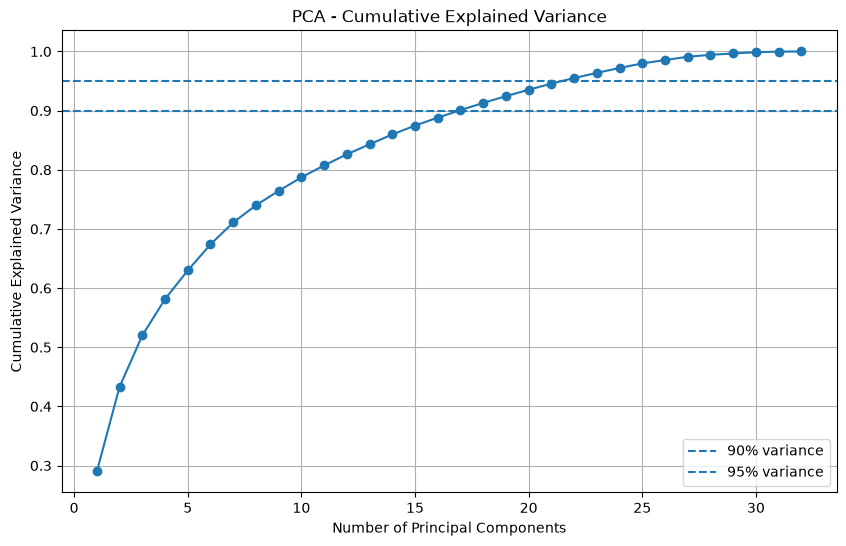

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(True)

plt.show()

In [58]:
# Keep enough principal components to explain at least 95% of the variance
n_components = 22

pca_final = PCA(n_components=n_components)

acoustic_pca_final = pca_final.fit_transform(acoustic_scaled)

print("Original number of acoustic variables:", acoustic_scaled.shape[1])
print("Number of principal components:", acoustic_pca_final.shape[1])
print(
    "Explained variance:",
    round(pca_final.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Original number of acoustic variables: 32
Number of principal components: 22
Explained variance: 95.52 %


In [59]:
pca_columns = [f"PC{i}" for i in range(1, n_components + 1)]

pca_df = pd.DataFrame(
    acoustic_pca_final,
    index=acoustic_features.index,
    columns=pca_columns
)

print("PCA dataset shape:", pca_df.shape)

pca_df.head()

PCA dataset shape: (106574, 22)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22
track_id,,,,,,,,,,,,,,,,,,,,,,
2,1.537662,-1.948755,0.157709,-0.674746,0.368239,0.020000,-1.932516,-0.309902,0.370108,-0.255082,0.063640,-0.435913,-0.047999,-1.619805,0.446361,0.055147,0.209524,-0.106160,-0.378577,-0.113627,-0.243626,-0.011387
3,2.548675,-1.519769,0.021196,0.036825,0.609313,0.622012,-1.331436,-0.237476,0.601659,-1.136639,-0.484504,-0.781185,0.303699,-0.164584,0.240872,-0.001241,0.031402,0.203415,-0.027965,-0.283727,-0.333050,-0.649282
5,1.729907,0.295689,0.314388,-0.521191,0.859978,-0.174822,-2.229371,-0.280464,-0.138764,-0.330526,1.535717,-0.721516,0.495485,-0.937255,0.142456,0.234860,0.315754,-1.092611,0.293076,0.435935,0.250351,-0.732161
10,0.601066,-1.546481,-0.555124,-1.135256,-0.419628,-0.291521,0.794333,-0.821438,0.843349,-0.448754,0.489225,0.275816,-0.133899,-0.456597,0.328415,0.197942,0.382275,0.313872,-0.018627,0.033866,0.272718,0.160318
20,2.529468,0.562786,1.811963,1.091317,-0.877966,-0.286290,0.783054,0.120749,0.515457,0.219861,-0.588556,-1.560474,-1.066644,0.382626,-0.487323,0.066617,-0.221694,0.001838,0.038228,0.282282,-0.176365,-0.584417


In [60]:
# Use a representative sample to choose the number of clusters
sample_size = 10000

pca_sample = pca_df.sample(
    n=sample_size,
    random_state=42
)

print("Sample shape:", pca_sample.shape)

Sample shape: (10000, 22)


In [61]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(pca_sample)
    inertias.append(kmeans.inertia_)

print("Elbow analysis completed.")

Elbow analysis completed.


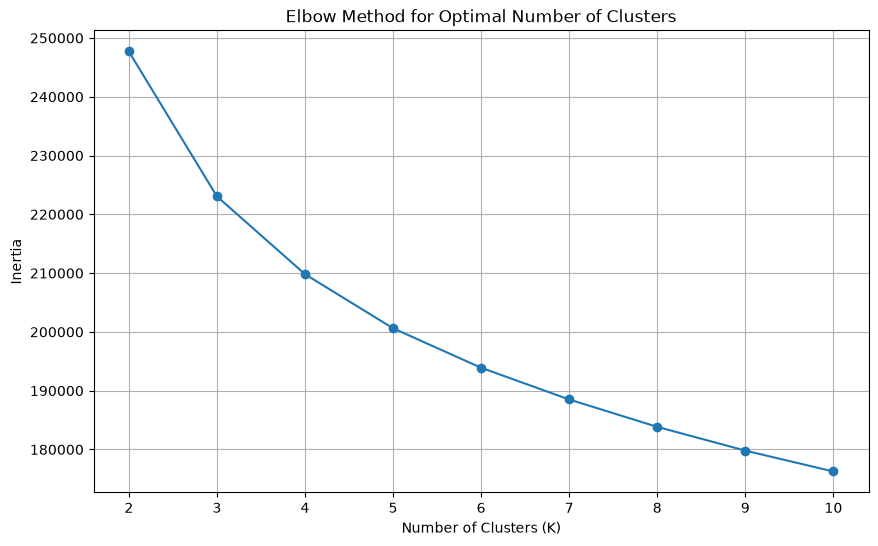

In [62]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [63]:
from sklearn.metrics import silhouette_score

# Test a smaller range of K values using the same sample
silhouette_scores = {}

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(pca_sample)
    
    score = silhouette_score(
        pca_sample,
        labels,
        sample_size=5000,
        random_state=42
    )
    
    silhouette_scores[k] = score
    
    print(f"K={k}: Silhouette Score = {score:.4f}")

K=2: Silhouette Score = 0.1955
K=3: Silhouette Score = 0.1251
K=4: Silhouette Score = 0.1016
K=5: Silhouette Score = 0.0911
K=6: Silhouette Score = 0.0852


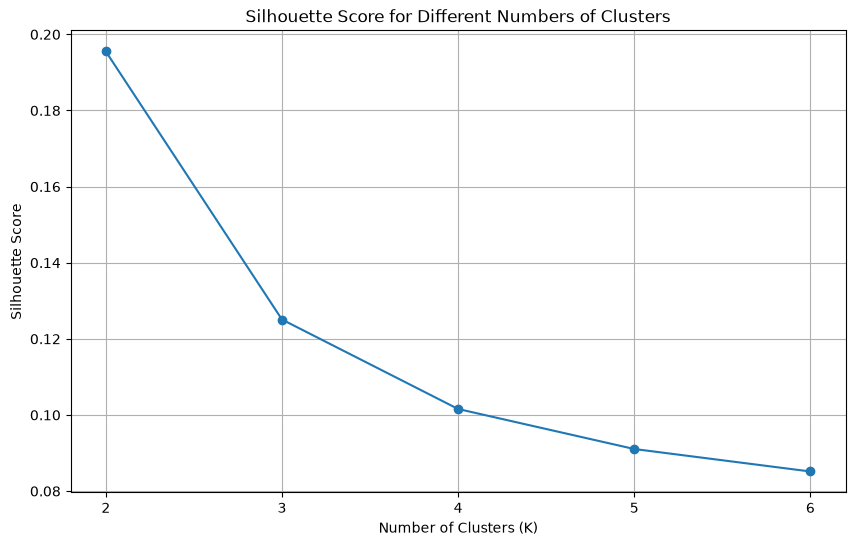

In [64]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xticks(range(2, 7))
plt.grid(True)

plt.show()

In [65]:
# Final K-Means model
final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(pca_df)

print("Clustering completed.")
print("Number of clusters:", final_k)
print("Number of songs clustered:", len(cluster_labels))

Clustering completed.
Number of clusters: 2
Number of songs clustered: 106574


In [66]:
# Add cluster assignments to the PCA dataset
pca_df["cluster"] = cluster_labels

print("Cluster distribution:")
print(pca_df["cluster"].value_counts().sort_index())

Cluster distribution:
cluster
0    42538
1    64036
Name: count, dtype: int64


In [67]:
# Combine cluster labels with the original track metadata
clustered_fma = track_metadata.copy()

clustered_fma["cluster"] = cluster_labels

print("Clustered FMA dataset shape:", clustered_fma.shape)

clustered_fma.head()


Clustered FMA dataset shape: (106574, 3)


,title,genre,cluster
track_id,,,
2,Food,Hip-Hop,1
3,Electric Ave,Hip-Hop,1
5,This World,Hip-Hop,1
10,Freeway,Pop,1
20,Spiritual Level,NaN,1


In [68]:
# Compare genre distribution across the two clusters

cluster_genres = pd.crosstab(
    clustered_fma["cluster"],
    clustered_fma["genre"]
)

print("Genre distribution by cluster:")
display(cluster_genres)

Genre distribution by cluster:


genre,Blues,Classical,Country,Easy Listening,Electronic,Experimental,Folk,Hip-Hop,Instrumental,International,Jazz,Old-Time / Historic,Pop,Rock,Soul-RnB,Spoken
cluster,,,,,,,,,,,,,,,,
0,67,1174,74,10,1837,4812,2225,305,1439,695,319,547,916,3046,19,244
1,43,56,120,14,7535,5796,578,3247,640,694,252,7,1416,11136,156,179


In [69]:
# Percentage of each genre within each cluster

cluster_genre_percent = pd.crosstab(
    clustered_fma["cluster"],
    clustered_fma["genre"],
    normalize="index"
) * 100

display(cluster_genre_percent.round(2))

genre,Blues,Classical,Country,Easy Listening,Electronic,Experimental,Folk,Hip-Hop,Instrumental,International,Jazz,Old-Time / Historic,Pop,Rock,Soul-RnB,Spoken
cluster,,,,,,,,,,,,,,,,
0,0.38,6.62,0.42,0.06,10.36,27.14,12.55,1.72,8.12,3.92,1.80,3.09,5.17,17.18,0.11,1.38
1,0.13,0.18,0.38,0.04,23.64,18.19,1.81,10.19,2.01,2.18,0.79,0.02,4.44,34.94,0.49,0.56


In [70]:
# Compare the average PCA values for each cluster

cluster_pca_means = (
    pca_df.groupby("cluster")
    .mean()
    .T
)

display(cluster_pca_means)

cluster,0,1
PC1,-2.989414,1.985815
PC2,0.048609,-0.032290
PC3,0.107047,-0.071110
PC4,0.051956,-0.034514
PC5,-0.074030,0.049177
PC6,0.029198,-0.019396
PC7,0.057827,-0.038414
PC8,0.006126,-0.004069
PC9,-0.025341,0.016834
PC10,-0.025397,0.016871


In [71]:
# Difference between Cluster 1 and Cluster 0

cluster_difference = (
    cluster_pca_means[1] - cluster_pca_means[0]
)

cluster_difference = cluster_difference.sort_values(
    key=abs,
    ascending=False
)

print("PCA components with the largest differences:")
display(cluster_difference)

PCA components with the largest differences:


PC1     4.975229
PC3    -0.178157
PC5     0.123207
PC7    -0.096241
PC4    -0.086470
PC2    -0.080899
PC6    -0.048593
PC10    0.042268
PC9     0.042175
PC13    0.039128
PC14    0.031032
PC15    0.026272
PC11   -0.022269
PC16   -0.020393
PC19    0.018744
PC18    0.017623
PC17    0.017286
PC12    0.016906
PC20   -0.015887
PC8    -0.010195
PC22   -0.009596
PC21   -0.001001
dtype: float64

In [72]:
# Identify the acoustic variables contributing most to PC1

pc1_loadings = pd.Series(
    pca_final.components_[0],
    index=acoustic_features.columns
)

pc1_loadings = pc1_loadings.sort_values(
    key=abs,
    ascending=False
)

print("Acoustic variables with the strongest contribution to PC1:")
display(pc1_loadings.head(15))

Acoustic variables with the strongest contribution to PC1:


mfcc_10                  0.244046
spectral_rolloff_01      0.241763
spectral_bandwidth_01    0.240155
mfcc_12                  0.237409
mfcc_08                  0.231493
spectral_centroid_01     0.227839
mfcc_14                  0.226888
spectral_contrast_04    -0.206005
spectral_contrast_03    -0.205379
spectral_contrast_02    -0.203324
spectral_contrast_05    -0.202926
spectral_contrast_07     0.202275
mfcc_06                  0.202031
mfcc_01                  0.196679
mfcc_16                  0.193212
dtype: float64

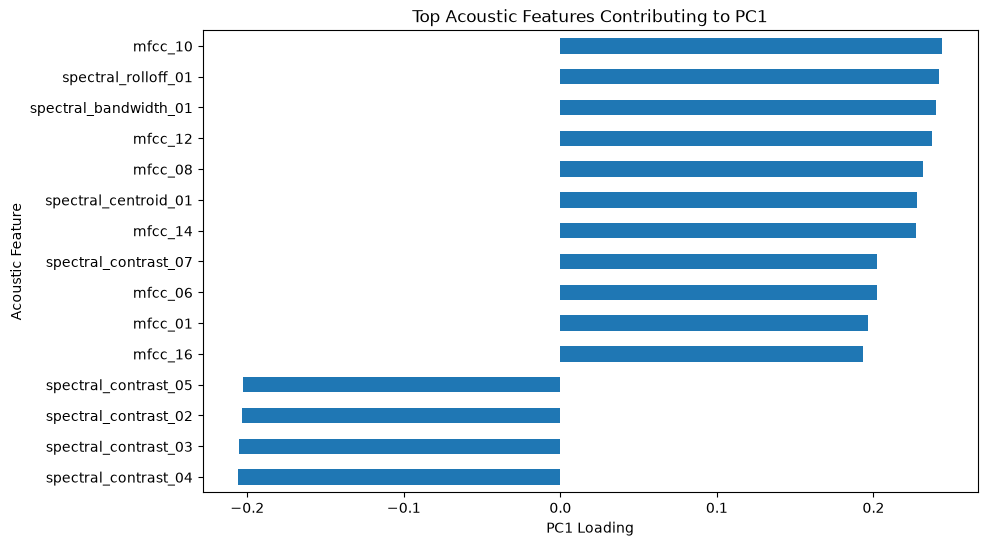

In [73]:
# Visualize the strongest PC1 loadings

pc1_loadings.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top Acoustic Features Contributing to PC1")
plt.xlabel("PC1 Loading")
plt.ylabel("Acoustic Feature")
plt.show()

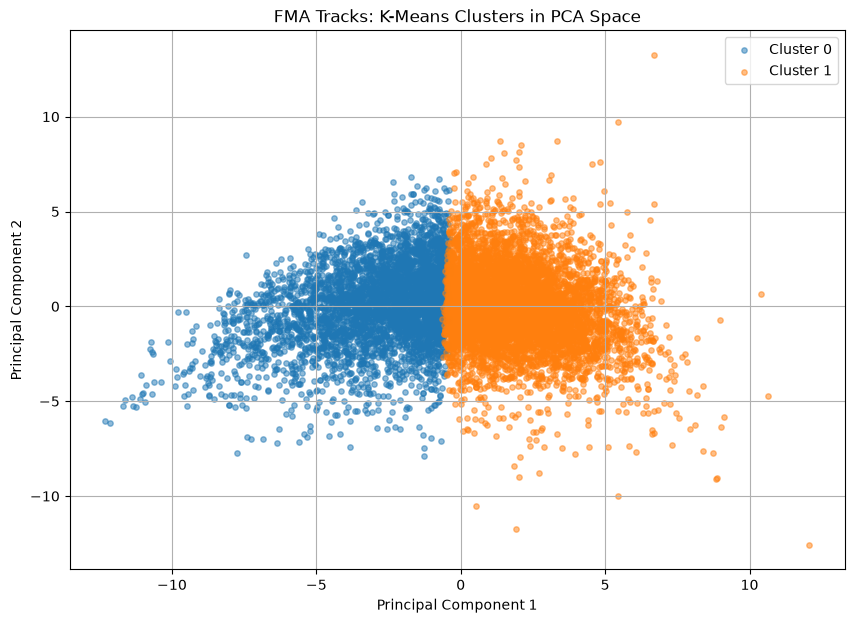

In [74]:
import matplotlib.pyplot as plt

# Plot a representative sample of the clustered songs
plot_sample = pca_df.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(10, 7))

for cluster in sorted(plot_sample["cluster"].unique()):
    cluster_data = plot_sample[
        plot_sample["cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.5,
        s=15
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("FMA Tracks: K-Means Clusters in PCA Space")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# Final cluster summary

cluster_summary = clustered_fma.groupby("cluster").agg(
    tracks=("title", "count"),
    unique_genres=("genre", "nunique")
)

cluster_summary["percentage"] = (
    cluster_summary["tracks"]
    / cluster_summary["tracks"].sum()
    * 100
)

display(cluster_summary.round(2))

,tracks,unique_genres,percentage
cluster,,,
0,42538,16,39.91
1,64035,16,60.09


In [76]:
cluster_summary = clustered_fma.groupby("cluster").agg(
    tracks=("cluster", "size"),
    unique_genres=("genre", "nunique")
)

cluster_summary["percentage"] = (
    cluster_summary["tracks"]
    / cluster_summary["tracks"].sum()
    * 100
)

display(cluster_summary.round(2))

,tracks,unique_genres,percentage
cluster,,,
0,42538,16,39.91
1,64036,16,60.09
